# NBM-SPAM: Learned unary bases with low-rank polynomial heads

NBM-SPAM learns unary NBM score channels, uses one segment linearly, and sends the remaining segments through degree-specific SPAM heads.


## Model in one view


Let $z_j^{(q)}(x_j)$ be unary NBM scores reserved for degree $q$. Then

$$
\eta(x)=\beta_0+\sum_j a_jz_j^{(1)}(x_j)
+\sum_{q=2}^{Q}\sum_{r=1}^{R_q}
\alpha_{qr}\left(\sum_jw_{qrj}z_j^{(q)}(x_j)\right)^q.
$$

Higher-order structure is created by SPAM; the NBM stage remains unary.



NBM-SPAM first learns nonlinear unary coordinates and then applies SPAM's
low-rank polynomial machinery to those coordinates. It can therefore express
interactions between learned feature shapes rather than only between raw
inputs. Separate subnet segments reserve channels for the linear and
higher-degree heads.

The decomposition is hierarchical: the NBM stage defines the coordinate
system and the SPAM stage defines polynomial interaction structure. Increasing
the number of bases, subnet replicas, degree, or rank expands different parts
of the model and should be tuned separately.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


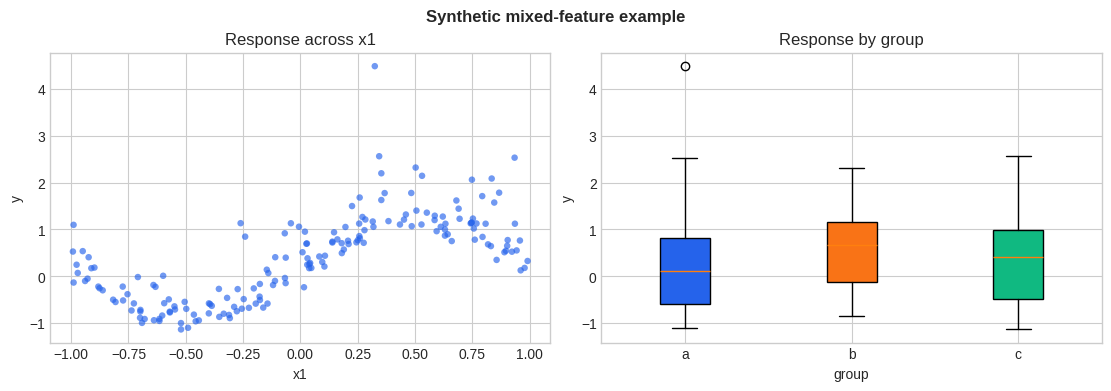

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import NBMSPAMClassifier, NBMSPAMLSS, NBMSPAMRegressor


model = NBMSPAMRegressor(
    num_bases=16,
    layer_sizes=[32, 16],
    ranks=[12],
    num_subnets=1,
    featurizer="conv1d",
    output_penalty=1e-4,
)
model.get_params(deep=False)


{'activation': torch.nn.modules.activation.ReLU,
 'bases_dropout': 0.0,
 'basis_l1_regularization': 0.0,
 'batch_norm': True,
 'dropout': 0.0,
 'featurizer': 'conv1d',
 'layer_norm': False,
 'layer_sizes': [32, 16],
 'lower_order_correction': False,
 'lr': 0.001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'norm': None,
 'num_bases': 16,
 'num_subnets': 1,
 'orthogonal': False,
 'output_penalty': 0.0001,
 'proximal': False,
 'ranks': [12],
 'reg_order': 2,
 'regularization_scale': 0.0,
 'skip_connections': False,
 'spam_dropout': 0.0,
 'use_glu': False,
 'weight_decay': 0.0,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'none',
 'categorical_preprocessing': 'one-hot',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': 'minmax',
 'n_knots': 64,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementat

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
`Trainer.fit` stopped: `max_epochs=3` reached.


{'R2': -0.08311079515143849, 'Mean Squared Error': 0.7559118663817773}

,term,term_type,output,importance
0,x2,main,0,0.005056
1,degree_2,main,0,0.004818
2,group[1],main,0,0.003883
3,x1,main,0,0.002826
4,group[0],main,0,0.000029
5,group[2],main,0,0.000007


,term,term_type,output,value,contribution,count,importance
0,x1,main,0,-0.965,-0.002051,2,0.002826
1,x1,main,0,-0.8895,-0.002403,2,0.002826
2,x1,main,0,-0.7905,-0.004535,2,0.002826
3,x1,main,0,-0.6915,-0.005710,2,0.002826
4,x1,main,0,-0.58,-0.006073,2,0.002826
5,x1,main,0,-0.4875,-0.005149,2,0.002826
6,x1,main,0,-0.35,-0.003042,1,0.002826
7,x1,main,0,-0.209,-0.002565,2,0.002826
8,x1,main,0,-0.12505,-0.001386,2,0.002826
9,x1,main,0,-0.05205,-0.000404,2,0.002826


## Evaluate and explain


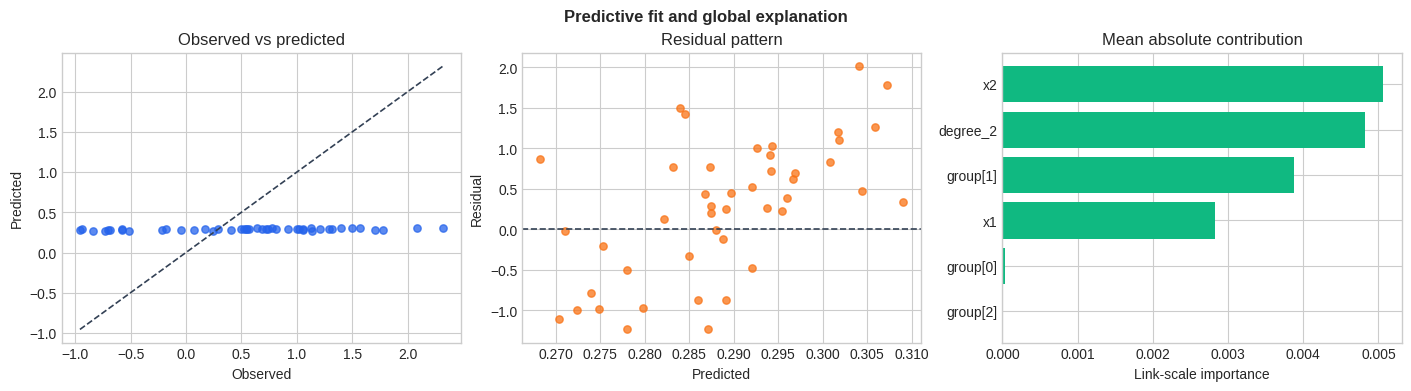

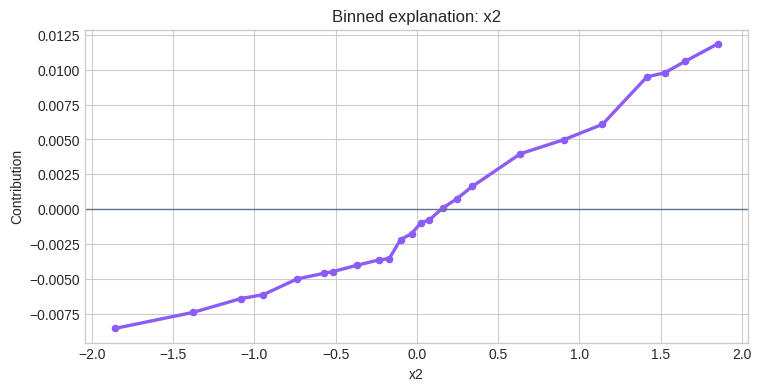

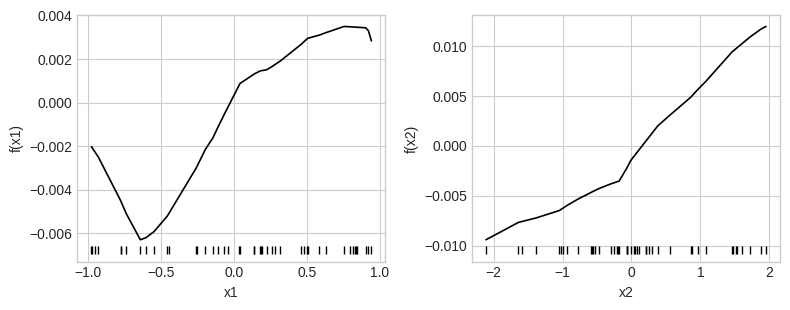

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

`ranks` sets the SPAM head rank for each polynomial degree. `num_subnets` controls replicated unary basis score channels per polynomial.


In [6]:
display({key: model.get_params(deep=False)[key] for key in ("ranks", "num_subnets", "featurizer")})
display(model.predict_components(X_test).terms.keys())


{'ranks': [12], 'num_subnets': 1, 'featurizer': 'conv1d'}

dict_keys(['x1', 'x2', 'group[0]', 'group[1]', 'group[2]', 'degree_2'])

## Supported task variants

NBM-SPAM provides regressor, classifier, and LSS estimators with the same hybrid decomposition.


In [7]:
task_variants = {"regression": NBMSPAMRegressor(), "classification": NBMSPAMClassifier(), "distributional": NBMSPAMLSS()}


## References

- [Neural Basis Models](https://arxiv.org/abs/2205.14120).
- [Scalable Polynomial Additive Models](https://arxiv.org/abs/2205.14108).
